Nome: João Lucas Morais Ortiz

RA: 297611

Curso: Ciências da Computação - Unesp (estudante especial)



# Ex05 - Classificação de imagens usando rede neural convolucional (CNN)

O objetivo principal deste notebook é ilustrar e praticar o uso de redes neurais convolucionais (CNNs) para tarefas de classificação de imagens. Em relação às redes neurais convencionais, as CNNs geralmente apresentam a vantagem de possuir menos parâmetros a serem aprendidos. Além disso, as CNNs são particularmente adequadas para trabalhar com imagens devido à sua arquitetura projetada para lidar com dados espaciais de forma eficiente.

Tomaremos como base a biblioteca PyTorch, que segue uma abordagem de programação orientada a objetos. Além dela, recomendamos o uso de outras bibliotecas relacionadas (como o PyTorch Lightning) que auxiliam e simplificam etapas do framework. Note que algumas destas bibliotecas podem não estar disponíveis por padrão no Colab ou sua máquina, sendo necessária sua instalação (como exemplificado na próxima célula de código).

Para mais informações sobre redes convolucionais, exemplos e boas práticas, recomendamos os materiais de apoio às aulas 5 e 6 disponibilizados no classroom. Lá você vai encontrar um tutorial teórico sobre CNN, além de tutoriais práticos disponibilizados no GitHub, vídeos e links de apoio.

**Atenção!** Não se esqueça de utilizar a GPU do Colab (clique em "Ambiente de execução" e "Alterar o tipo de ambiente de execução", selecione a GPU).

In [2]:
# Instalando bibliotecas
!pip install pytorch-lightning torchinfo torchmetrics torch-summary medmnist tensorboard

Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached grpcio-1.80.0.tar.gz (13.0 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached markdown-3.10.2-py3-none-any.whl.metadata (5.1 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
Using cached tensorboard-2.20.0-py3-none-any.whl (5.5 MB)
Using cached tensorboard_data_server-0.7.2-py3-none-any.whl (2.4 kB)
Using cached absl_py-2.4.0-py3-none-any.whl (135 kB)
Using cached markdown-3.10.2-py3-none-any.whl (108 kB)
Failed to build grpcio


  error: subprocess-exited-with-error
  
  × Building wheel for grpcio (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [12005 lines of output]
      SSE2 not enabled on win-arm64 platform
      ASM Builds for BoringSSL currently not supported on: win-arm64
      Found cython-generated files...
      running bdist_wheel
      running build
      running build_py
      running build_project_metadata
      creating pyb\lib.win-arm64-cpython-311\grpc
      copying src\python\grpcio\grpc\_auth.py -> pyb\lib.win-arm64-cpython-311\grpc
      copying src\python\grpcio\grpc\_channel.py -> pyb\lib.win-arm64-cpython-311\grpc
      copying src\python\grpcio\grpc\_common.py -> pyb\lib.win-arm64-cpython-311\grpc
      copying src\python\grpcio\grpc\_compression.py -> pyb\lib.win-arm64-cpython-311\grpc
      copying src\python\grpcio\grpc\_grpcio_metadata.py -> pyb\lib.win-arm64-cpython-311\grpc
      copying src\python\grpcio\grpc\_interceptor.py -> pyb\lib.win-arm64-cpython-311\gr

In [3]:
# Importando as bibliotecas que serão utilizadas
import multiprocessing as mp
import os
import random
import sys
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
import torch
import torchinfo
from medmnist import DermaMNIST
from pytorch_lightning.callbacks import ModelCheckpoint
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset
from torchmetrics import Accuracy
from torchsummary import summary
from torchvision import datasets, models
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid

#%load_ext tensorboard

In [4]:
torch.set_float32_matmul_precision('medium')

## Parte 1 - Exemplo de classificação com o MNIST

Exemplificaremos algumas das etapas do framework de classificação com CNN utilizando o conjunto de dados MNIST (Modified National Institute of Standards and Technology database), um grande conjunto de dados de dígitos manuscritos comumente usado na área de aprendizado de máquina. Ele consiste de 60.000 imagens de treinamento e 10.000 images de teste (que, no nosso exemplo, serão utilizadas para validação). As imagens do conjunto são de 28x28 pixels. Uma descrição completa do conjunto de dados pode ser encontrada [aqui](https://en.wikipedia.org/wiki/MNIST_database).

### Leitura dos dados

Idealmente, códigos para processar amostras de dados devem estar desacoplados do código do treinamento do modelo, facilitando sua legibilidade e modularidade. O PyTorch fornece duas primitivas de dados ([torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) e [torch.utils.data.Dataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset)) que facilitam a leitura, processamento e organização dos dados para entrada no modelo. Mais informações sobre Datasets e DataLoaders podem ser encontradas [aqui](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) e [aqui](https://blog.paperspace.com/dataloaders-abstractions-pytorch/).

In [5]:

# Carregando os dados utilizando torchvision.datasets e convertendo as imagens para tensores
training_data = datasets.MNIST(
    root="data_mnist",
    train=True,
    download=True,
    transform=ToTensor()
)
val_data = datasets.MNIST(
    root="data_mnist",
    train=False,
    download=True,
    transform=ToTensor()
)

print(training_data)
print()
print(val_data)
print()
print("*Note que, apesar de identificado como teste, utilizaremos o segundo conjunto de dados para validação!")

Dataset MNIST
    Number of datapoints: 60000
    Root location: data_mnist
    Split: Train
    StandardTransform
Transform: ToTensor()

Dataset MNIST
    Number of datapoints: 10000
    Root location: data_mnist
    Split: Test
    StandardTransform
Transform: ToTensor()

*Note que, apesar de identificado como teste, utilizaremos o segundo conjunto de dados para validação!


**É sempre importante checar e visualizar os dados a cada etapa do framework de classificação, garantindo que eles estão de acordo com o esperado e evitando a propagação de erros.**

2
<class 'torch.Tensor'> <class 'int'>
Shape da imagem: torch.Size([1, 28, 28])
Label: 0
Maior valor de intensidade da imagem: tensor(1.)
Menor valor de intensidade da imagem: tensor(0.)


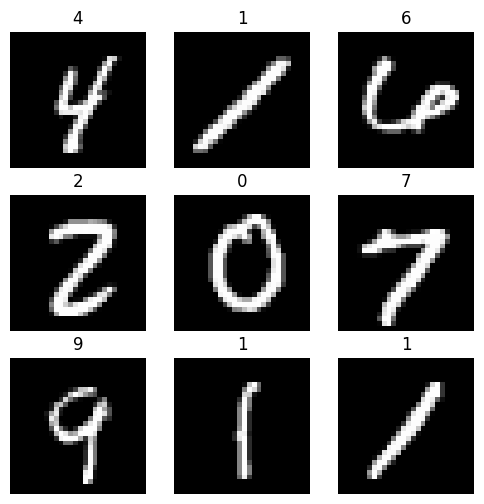

In [6]:
# Checando informações de uma amostra de treinamento
training_example = random.choice(training_data)
print(len(training_example))
print(type(training_example[0]), type(training_example[1]))
print('Shape da imagem:', training_example[0].shape)
print('Label:', training_example[1])
print('Maior valor de intensidade da imagem:', torch.max(training_example[0]))
print('Menor valor de intensidade da imagem:', torch.min(training_example[0]))

# Visualizando algumas imagens e labels do conjunto de treinamento
figure = plt.figure(figsize=(6, 6))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    img, label = random.choice(training_data)
    plt.subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
plt.show()

2
<class 'torch.Tensor'> <class 'int'>
Shape da imagem: torch.Size([1, 28, 28])
Label: 2
Maior valor de intensidade da imagem: tensor(1.)
Menor valor de intensidade da imagem: tensor(0.)


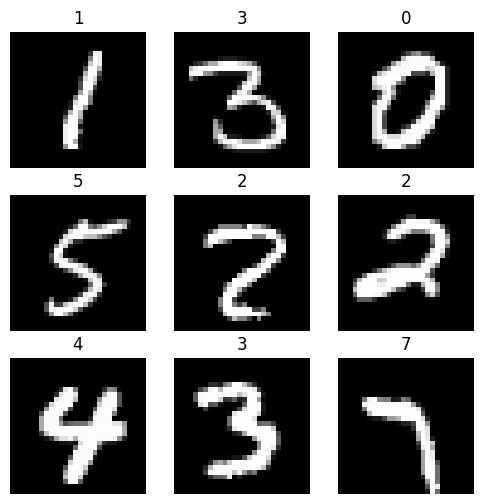

In [7]:
# Checando informações de uma amostra de validação
val_example = random.choice(val_data)
print(len(val_example))
print(type(val_example[0]), type(val_example[1]))
print('Shape da imagem:', val_example[0].shape)
print('Label:', val_example[1])
print('Maior valor de intensidade da imagem:', torch.max(val_example[0]))
print('Menor valor de intensidade da imagem:', torch.min(val_example[0]))

# Visualizando algumas imagens e labels do conjunto de validação
figure = plt.figure(figsize=(6, 6))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    img, label = random.choice(val_data)
    plt.subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
plt.show()

### Exercício 1.1

Explique o processamento aplicado pela classe torchvision.transforms.ToTensor às imagens do conjunto. Explique também porque foi necessário utilizar o .squeeze() para visualizar as imagens e qual a sua função.

RESPOSTA: O método ToTensor realiza três transformações principais: 1º converte a imagem de um array NumPy ou PIL para um tensor PyTorch; Então normaliza os valores de pixel do intervalo [0, 255] para [0, 1], dividindo cada pixel por 255; Por fim reorganiza as dimensões de (Height, Width, Chanel) para (Chanel, Height, Width), o formato esperado pelo PyTorch (para MNIST: de (28, 28, 1) para (1, 28, 28)). O método .squeeze() remove dimensões de tamanho 1 do tensor. Como as imagens MNIST têm apenas 1 canal após ToTensor (dimensão 1), aplicar .squeeze() converte (1, 28, 28) para (28, 28), removendo a dimensão do canal. Isso é necessário para visualizar a imagem com matplotlib, pois a função imshow() espera uma matriz 2D para exibir em escala de cinza, não um tensor 3D.

### Hiperparâmetros

É interessante utilizar um dicionário de hiperparâmetros para organizar o código, evitar "números mágicos" e registrar as configurações de cada experimento realizado.

In [8]:
hparams = {"experiment_name": "Test_ResNet_1",  # experiment name identifies the run for later
           "max_epochs": 10,  # number of epochs to train
           "batch_size": 100,  # size of batch
           "nworkers": 2 if sys.platform.startswith("win") else mp.cpu_count(),  # number of workers to use in parallel loading
           "nout": 10,  # number of classes
           "nin": 1,  # number of channels of the input image
           "lr": 1e-4,  # learning rate
           "wd": 1e-5,  # weight decay for optimizer
           "cpu": False,  # forces using the CPU
           }

for k, v in hparams.items():
    print(f"{k}: {v}")

experiment_name: Test_ResNet_1
max_epochs: 10
batch_size: 100
nworkers: 2
nout: 10
nin: 1
lr: 0.0001
wd: 1e-05
cpu: False


### Data Module

A classe [pytorch_lightning.LightningDataModule](https://lightning.ai/docs/pytorch/stable/data/datamodule.html) pode ser utilizada para organizar os DataLoaders e os dados.

In [9]:
class MNISTDataModule(pl.LightningDataModule):
    def __init__(self, hparams):
        super().__init__()
        self.save_hyperparameters(hparams)

    def setup(self, stage=None):
        self.train = training_data
        self.val = val_data

    '''
    Dataloaders optimize data loading and automatically prepare batches
    '''
    def train_dataloader(self):
        return DataLoader(self.train, 
                            batch_size=self.hparams.batch_size, 
                            num_workers=self.hparams.nworkers, 
                            shuffle=True,
                            persistent_workers=True,
                            pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val, 
                          batch_size=self.hparams.batch_size, 
                          num_workers=self.hparams.nworkers, 
                          shuffle=False,
                          persistent_workers=True,
                          pin_memory=True)

**Novamente, checamos os dados obtidos através do DataModule.**

C:\Users\jluca\AppData\Roaming\Python\Python311-arm64\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Shape do batch: torch.Size([100, 1, 28, 28])


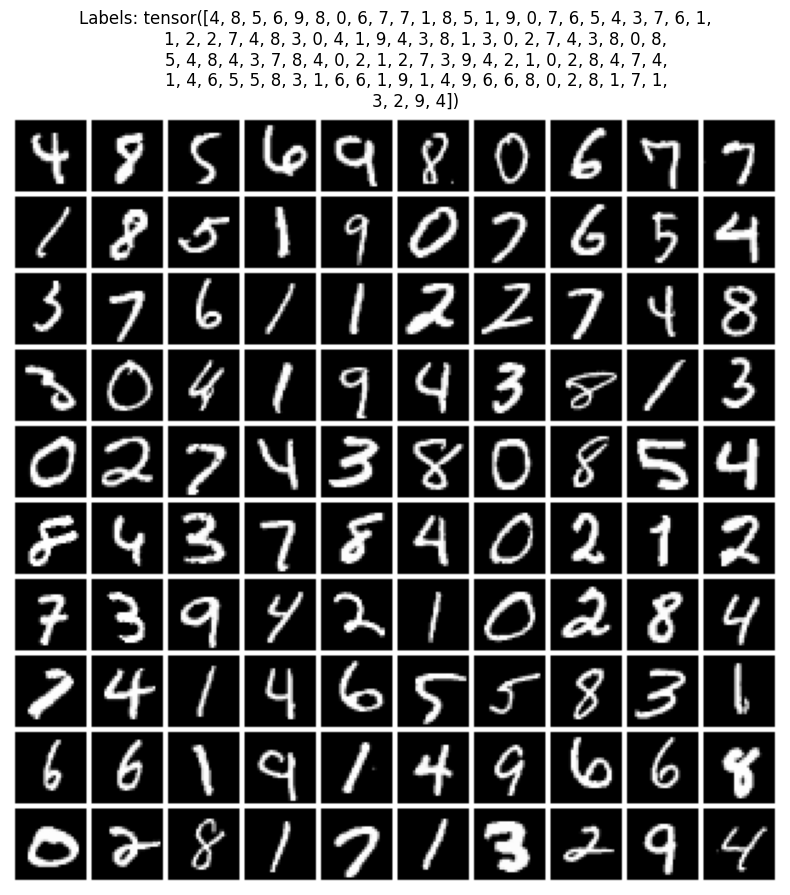

In [10]:
# DEBUG DATA MODULE
data_module = MNISTDataModule(hparams)
data_module.setup()

check_dataloader = data_module.train_dataloader()
img_batch, label_batch = next(iter(check_dataloader))
print("Shape do batch:", img_batch.shape)

img_grid = make_grid(img_batch, nrow=10, pad_value=1)
fig = plt.figure(figsize=(10,10))
plt.imshow(img_grid.permute(1, 2, 0).numpy())
plt.title(f'Labels: {label_batch}')
plt.axis('off')
plt.show()

### Definindo a CNN

No código abaixo, é criado um modelo baseado na [Resnet-18](https://pytorch.org/vision/master/models/generated/torchvision.models.resnet18.html). O mesmo será treinado **sem transfer learning** e com uma inicialização randômica dos pesos. Visualizamos também todas as camadas (layers) que compõem o modelo e seus parâmetros.

In [11]:
cnn_model = models.resnet18(weights=None)
print(cnn_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [12]:
cnn_model.conv1 = nn.Conv2d(hparams['nin'], 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
num_ftrs = cnn_model.fc.in_features
cnn_model.fc = nn.Linear(num_ftrs, hparams['nout'])
print(cnn_model)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Exercício 1.2

Para que serve cada camada da rede? Por que foi necessário modificar ligeiramente a rede (célula anterior) e que modificações foram realizadas?

RESPOSTA: Na ResNet, as primeiras camadas convolucionais extraem padrões simples (bordas, cantos e texturas). À medida que a imagem passa pelos blocos residuais (layer1 a layer4), a rede aprende características mais complexas. As camadas de normalização e ativação (BatchNorm + ReLU) estabilizam e tornam o treinamento mais eficiente. As camadas de pooling reduzem a resolução espacial, preservando informação relevante e reduzindo custo computacional. No final, a camada totalmente conectada (fc) transforma as características extraídas em pontuações de classe.

Foi necessário modificar a rede para adaptá-la ao problema MNIST: as imagens têm 1 canal (cinza), enquanto a ResNet original espera 3 canais (RGB), e o problema possui 10 classes de saída. Por isso, foram feitas duas mudanças principais: 1º conv1 foi alterada para receber 1 canal de entrada (nin=1); e também a camada final fc foi trocada para produzir 10 saídas. Nós ajustamos a arquitetura de entrada e saída ao dataset.

### Resumo do modelo

In [13]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
cnn_model.to(device)
summary(cnn_model, (1, 28, 28))

cpu
Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 14, 14]          3,136
├─BatchNorm2d: 1-2                       [-1, 64, 14, 14]          128
├─ReLU: 1-3                              [-1, 64, 14, 14]          --
├─MaxPool2d: 1-4                         [-1, 64, 7, 7]            --
├─Sequential: 1-5                        [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-1                   [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-1                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-3                    [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-4                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-6                    [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-2                   [-1, 64, 7, 7]            

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 14, 14]          3,136
├─BatchNorm2d: 1-2                       [-1, 64, 14, 14]          128
├─ReLU: 1-3                              [-1, 64, 14, 14]          --
├─MaxPool2d: 1-4                         [-1, 64, 7, 7]            --
├─Sequential: 1-5                        [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-1                   [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-1                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-3                    [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-4                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-6                    [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-2                   [-1, 64, 7, 7]            --
|

### Exercício 1.3

Tente entender as dimensões da saída de cada camada da rede. Por exemplo, porque as três primeiras camadas possuem saídas com dimensões (-1, 64, 14, 14) e a quarta camada tem saída com dimensões (-1, 64, 7, 7)?

E quanto aos parâmetros a serem aprendidos, você consegue explicar como eles são calculados?

RESPOSTA: A ideia principal é: tanto o stride quanto o pooling controlam o quanto a imagem é "encolhida" ao longo da rede.

- Stride é o "passo" com que o filtro anda sobre a imagem.  
  Se stride = 1, o filtro anda de 1 em 1 pixel (quase não reduz a dimensão).  
  Se stride = 2, ele pula de 2 em 2 pixels, então a saída fica menor (aproximadamente metade em altura e largura).

- MaxPool é um tipo de pooling (a camada de pooling): ele pega uma pedaço (por exemplo 2x2) e mantém só o maior valor daquela região.  
  Além de resumir a informação mais forte, ele também reduz dimensão espacial. Com kernel=2 e stride=2, normalmente reduz de 14x14 para 7x7.

No início da ResNet a conv1 usa stride=2, então 28x28 vira 14x14; depois o maxpool reduz 14x14 para 7x7. Por isso aparecem saídas com 14x14 e depois 7x7.

Os parâmetros treináveis são os pesos e vieses das camadas (principalmente convoluções e camada totalmente conectada). O backpropagation calcula os gradientes para atualizar esses parâmetros. A quantidade de parâmetros de uma convolução é dada por: out_channels × in_channels × kernel_h × kernel_w (somando + out_channels se houver bias). Na camada linear final, é: in_features × out_features (somando + out_features se houver bias).

### Lightning Module

Aqui definimos o comportamento durante o treinamento, ou seja, o que acontece com um lote retornado pelo DataLoader.

In [14]:
class TrainMNIST(pl.LightningModule):
    def __init__(self, hparams):
        super().__init__()

        self.save_hyperparameters(hparams)
        self.model = cnn_model
        self.loss = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task="multiclass", num_classes=self.hparams.nout)

        torchinfo.summary(self.model)

    def forward(self, x):
        return self.model(x).softmax(dim=-1)

    def classification_step(self, mode, batch):
        x, y = batch
        y_hat = self.forward(x)
        loss = self.loss(y_hat, y)

        if mode == "train":
            self.log("loss", loss, on_epoch=True, on_step=True)
            return loss
        elif mode == "val":
            _, preds = torch.max(y_hat, 1)
            self.accuracy(preds, y)
            self.log("val_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
            self.log("val_acc", self.accuracy, on_epoch=True, on_step=False, prog_bar=True)

    def training_step(self, train_batch, batch_idx):
        return self.classification_step("train", train_batch)

    def validation_step(self, val_batch, batch_idx):
        self.classification_step("val", val_batch)

    def configure_optimizers(self):
        optimizer = AdamW(self.model.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.wd)

        return optimizer

### Treinando a CNN

In [15]:
debug = False  # Turn this True to test the code with a quick run

# Initialization
model = TrainMNIST(hparams)
data = MNISTDataModule(hparams)

# The PL trainer can run various callbacks during training. Here we only use the
# callback that saves the weights of the trained network.
os.makedirs("logs", exist_ok=True)
checkpoint_callback = [ModelCheckpoint(dirpath="logs",  # path to save checkpoint
                                       filename=hparams["experiment_name"] + "-{epoch}-{val_acc:.2f}",
                                       monitor="val_acc",
                                       mode="max")]

trainer = pl.Trainer(max_epochs=hparams["max_epochs"], #devices=1, accelerator="gpu",
                     fast_dev_run=debug,
                     callbacks=checkpoint_callback,
                     log_every_n_steps=1
                     )

print("Hyperparameters:\n")
for k, v in hparams.items():
    print(f'{k}: {v}')

trainer.fit(model, data)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
C:\Users\jluca\AppData\Roaming\Python\Python311-arm64\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Hyperparameters:

experiment_name: Test_ResNet_1
max_epochs: 10
batch_size: 100
nworkers: 2
nout: 10
nin: 1
lr: 0.0001
wd: 1e-05
cpu: False


C:\Users\jluca\AppData\Roaming\Python\Python311-arm64\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory D:\2026s1-pi05-cnn-JoaoLucasMoraisOrtiz\logs exists and is not empty.


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model    │ ResNet             │ 11.2 M │ train │     0 │
│ 1 │ loss     │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ accuracy │ MulticlassAccuracy │      0 │ train │     0 │
└───┴──────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 70                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

C:\Users\jluca\AppData\Roaming\Python\Python311-arm64\site-packages\pytorch_lightning\utilities\_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

`Trainer.fit` stopped: `max_epochs=10` reached.


### Visualizando os logs de treinamento

Por padrão, o Pytorch Lightning registra os resultados do treinamento usando o TensorBoard. Você pode configurar muitos outros registradores (https://pytorch-lightning.readthedocs.io/en/stable/extensions/logging.html), recomendamos verificar o Neptune ou o MLFlow. Utilize esses registradores para comparar experimentos!

Abaixo é possível verificar os resultados do treinamento realizado previamente (disponibilizado no diretório **Dados/Ex05/saved_lightning_logs**).

In [ ]:
#%tensorboard --logdir lightning_logs

UsageError: Line magic function `%tensorboard` not found.


### Análise dos resultados

Após o treinamento da rede, é importante checar os resultados de validação, visualizando algumas saídas da rede e obtendo métricas de classificação. Abaixo exemplificamos a visualização da matriz de confusão.

In [22]:
# WARNING: This will load a random checkpoint from the logs folder, if you want an specific one change it!
baseline_model = random.choice(glob("logs/*.ckpt"))
print(f"Using model {baseline_model}")

# Load trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TrainMNIST.load_from_checkpoint(baseline_model).eval().to(device)

# Rebuild validation dataset explicitly to avoid notebook-state variable shadowing
val_dataset_eval = datasets.MNIST(
    root="data_mnist",
    train=False,
    download=True,
    transform=ToTensor(),
)

# Use single-process loading here to avoid multiprocessing pickling issues on Windows/Jupyter
val_data = DataLoader(
    val_dataset_eval,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    persistent_workers=False,
    pin_memory=False,
)

def collect_2d_results(data_loader, model, device):
    y_trues = []
    y_labels = []
    for (img, label) in data_loader:
        img = img.to(device)
        with torch.no_grad():
            out = model(img).argmax(dim=-1).item()

        y_trues.append(int(label.item()))
        y_labels.append(out)

    return y_trues, y_labels

y_trues_val, y_labels_val = collect_2d_results(val_data, model, device)

Using model logs\Test_ResNet_1-epoch=9-val_acc=0.99.ckpt


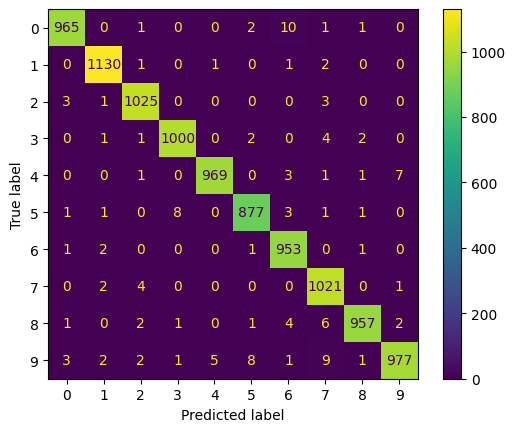

In [23]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_trues_val, y_labels_val, labels=np.arange(10)),
                                display_labels=np.arange(10))
fig = disp.plot(ax=None).figure_
plt.show()

Por fim, o modelo final seria avaliado em um conjunto de teste (que não está disponível no exemplo apresentado). **Vale ressaltar que o conjunto de teste não deve ser utilizado para refinar o modelo! Ele deve ser utilizado apenas para uma avaliação final do modelo.**

## Parte 2 - Classificação com o DermaMNIST

Vamos retomar a classificação do dataset de imagens dermatoscópicas de lesões de pele comuns, utilizado no Exercício 02. Desta vez, ao invés de extrair os atributos "artesanalmente" e classificar com o KNN, utilizaremos CNNs para realizar os dois processos simultaneamente (extração de atributos + classificação).

**Dataset**

O dataset consiste em 600 imagens de lesões de pele, obtidas ao longo de 20 anos em dois hospitais diferentes. Como as imagens foram obtidas e armazenadas de diferentes formas ao longo do tempo (armazenadas em arquivos PowerPoint, por exemplo), elas passaram por um processo de seleção, organização e padronização para compor o dataset. Assim, as imagens foram cortadas em torno das lesões de modo a deixá-las centralizadas e, em alguns casos, tiveram seus histogramas corrigidos manualmente para melhorar o contraste visual e a reprodução de cores.

As imagens estão divididas em dois tipos de lesão de pele:
- 300 casos de carcinoma basocelular (label 0) - um tipo de câncer de pele que começa nas células basais, raramente apresenta metástase, mas cresce de forma destrutiva se não tratado;
- 300 casos de melanoma (label 1) - o tipo mais grave de câncer de pele, que começa nas células produtoras de melanina, é quase sempre curável em estágios iniciais, mas tende a apresentar metástase com o tempo.

O dataset está separado em um conjunto de treino com 400 imagens (200 de cada classe), um conjunto de validação com 100 imagens (50 de cada classe) e um conjunto de teste com 100 imagens (50 de cada classe). As imagens devem ser classificadas em 0 ou 1, representando os dois tipos de lesões presentes no dataset (carcinoma ou melanoma, respectivamente).

### Exercício 2.1

Com base no exemplo apresentado e nos materiais de apoio disponibilizados, treine uma CNN para classificar as lesões de pele. Considere as recomendações abaixo:

- Considere aplicar [transformações](https://pytorch.org/vision/stable/transforms.html) durante a leitura dos dados, seja para normalizá-los ou realizar aumentação de dados.
- Lembre-se de sempre checar os dados!
- Você pode definir sua própria rede ou utilizar modelos de classificação disponibilizados pelo PyTorch (como a [ResNet](https://pytorch.org/vision/stable/models/resnet.html) ou a [EfficientNet](https://pytorch.org/vision/stable/models/efficientnet.html)). Caso utilize modelos disponibilizados, tome cuidado com as entradas e saídas da rede, talvez seja necessário realizar algumas modificações (como no exemplo apresentado). Considere também a utilização de modelos pré-treinados, eles apresentam resultados melhores do que modelos inicializados com pesos randômicos?
- Note que, no exemplo apresentado, os checkpoints da rede e os logs do PyTorch Lightning ficam salvos no ambiente de execução do Colab. Tome cuidado para não acabar perdendo experimentos! Você pode alterar o local em que esses arquivos são salvos para que sejam armazenados no seu Drive ou ainda salvar manualmente os arquivos que julgar importantes.
- Tente modificar os hiperparâmetros para obter melhores resultados de validação.
- Verifique os resultados do modelo: visualize algumas saídas da rede e obtenha métricas de classificação (acurácia, precisão, revocação e F1-score), além de imprimir a matriz de confusão.
- Idealmente, você deve avaliar apenas o modelo final no conjunto de teste.

Comente os métodos utilizados e resultados obtidos, tentando justificar as decisões que foram tomadas. Compare também os resultados obtidos através da CNN com os resultados obtidos através do KNN no Exercício 02.

In [24]:
#Código base para leitura dos dados

train_dataset_base = DermaMNIST(
    split="train",
    download=True 
)

test_dataset_base = DermaMNIST(
    split="test",
    download=True
)

images_train = []
labels_train = []
images_test = []
labels_test = []

datasets = {"train":train_dataset_base, "test":test_dataset_base}
img_count = {"train":200, "test":50}
images : dict[str, list[np.ndarray]] = {}
labels : dict[str, list[int]] = {}

for split in datasets:
    dataset = datasets[split]
    images[split] = []
    labels[split] = []
    
    counter = {0:0, 1:0}

    for data in dataset:
        img = data[0]
        label = data[1].item()
        if label == 1:
            label = 0
        elif label == 4:
            label = 1
        else:
            continue

        if counter[label] >= img_count[split]:
            continue

        images[split].append(np.array(img))
        labels[split].append(label)

        counter[label] += 1



images_train = images["train"]
labels_train = labels["train"]
images_test = images["test"]
labels_test = labels["test"]

train_dataset = TensorDataset(torch.tensor(images_train), torch.tensor(labels_train))
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

test_dataset = TensorDataset(torch.tensor(images_test), torch.tensor(labels_test))
test_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

C:\Users\jluca\AppData\Local\Temp\ipykernel_15780\3680629116.py:55: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\a\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  train_dataset = TensorDataset(torch.tensor(images_train), torch.tensor(labels_train))


In [ ]:
# Checagem explícita de dimensões e compatibilidade com a ResNet18
x_dbg, y_dbg = next(iter(train_loader_21))
print("Shape do batch:", x_dbg.shape)
print("Shape dos rótulos:", y_dbg.shape)
print("Dtype:", x_dbg.dtype)
print("Faixa de valores [min, max]:", float(x_dbg.min()), float(x_dbg.max()))

assert x_dbg.ndim == 4, "Esperado tensor 4D [B, C, H, W]"
assert x_dbg.shape[1] == 3, f"Esperado 3 canais (RGB), recebido {x_dbg.shape[1]}"
assert x_dbg.shape[2] == 28 and x_dbg.shape[3] == 28, f"Esperado 28x28, recebido {x_dbg.shape[2:]}"

# Teste rápido de forward para garantir compatibilidade de entrada/saída
device_dbg = next(cnn_model_21.parameters()).device
with torch.no_grad():
    logits_dbg = cnn_model_21(x_dbg[:2].to(device_dbg))

print("Shape da saída da rede:", logits_dbg.shape)
assert logits_dbg.shape[1] == 2, "A camada final deve produzir 2 classes"
print("Checagem concluída: dimensões compatíveis com a rede.")

In [ ]:
import math
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from torchvision import transforms as T
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------
# 1) Preparação dos dados (train/val/test) e checagem de classes
# ------------------------------------------------------------
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

x_train = np.array(images_train, dtype=np.uint8)  # [N, H, W, C]
y_train = np.array(labels_train, dtype=np.int64)
x_test = np.array(images_test, dtype=np.uint8)
y_test = np.array(labels_test, dtype=np.int64)

print("Distribuição original:")
print("Treino:", {int(c): int((y_train == c).sum()) for c in np.unique(y_train)})
print("Teste :", {int(c): int((y_test == c).sum()) for c in np.unique(y_test)})

# Split estratificado simples (20% para validação)
val_fraction = 0.2
train_idx, val_idx = [], []

for cls in np.unique(y_train):
    idx_cls = np.where(y_train == cls)[0]
    np.random.shuffle(idx_cls)
    n_val = max(1, int(math.ceil(len(idx_cls) * val_fraction)))

    val_idx.extend(idx_cls[:n_val].tolist())
    train_idx.extend(idx_cls[n_val:].tolist())

train_idx = np.array(train_idx)
val_idx = np.array(val_idx)

x_tr, y_tr = x_train[train_idx], y_train[train_idx]
x_val, y_val = x_train[val_idx], y_train[val_idx]

print("\nApós split treino/val:")
print("Treino:", {int(c): int((y_tr == c).sum()) for c in np.unique(y_tr)})
print("Val   :", {int(c): int((y_val == c).sum()) for c in np.unique(y_val)})


class DermaBinaryDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = int(self.labels[idx])

        img_pil = Image.fromarray(img)
        if self.transform is not None:
            img_tensor = self.transform(img_pil)
        else:
            img_tensor = T.ToTensor()(img_pil)

        return img_tensor, label


train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.3),
    T.RandomRotation(degrees=20),
    T.ToTensor(),
])

val_test_transform = T.Compose([
    T.ToTensor(),
])

train_dataset_21 = DermaBinaryDataset(x_tr, y_tr, transform=train_transform)
val_dataset_21 = DermaBinaryDataset(x_val, y_val, transform=val_test_transform)
test_dataset_21 = DermaBinaryDataset(x_test, y_test, transform=val_test_transform)

batch_size_21 = 32
nworkers_21 = 2 if sys.platform.startswith("win") else mp.cpu_count()

train_loader_21 = DataLoader(train_dataset_21, batch_size=batch_size_21, shuffle=True, num_workers=nworkers_21)
val_loader_21 = DataLoader(val_dataset_21, batch_size=batch_size_21, shuffle=False, num_workers=nworkers_21)
test_loader_21 = DataLoader(test_dataset_21, batch_size=batch_size_21, shuffle=False, num_workers=nworkers_21)

# Checando formato do batch
x_batch, y_batch = next(iter(train_loader_21))
print("\nShape batch:", x_batch.shape, "| labels:", y_batch.shape)


# ------------------------------------------------------------
# 2) Modelo + treinamento
# ------------------------------------------------------------
hparams_21 = {
    "experiment_name": "Ex2_1_Derma_ResNet18",
    "max_epochs": 12,
    "lr": 1e-4,
    "wd": 1e-4,
    "nout": 2,
}

cnn_model_21 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_ftrs_21 = cnn_model_21.fc.in_features
cnn_model_21.fc = nn.Linear(num_ftrs_21, hparams_21["nout"])


class TrainDerma(pl.LightningModule):
    def __init__(self, hparams, model):
        super().__init__()
        self.save_hyperparameters(hparams)
        self.model = model
        self.loss_fn = nn.CrossEntropyLoss()
        self.val_acc = Accuracy(task="multiclass", num_classes=self.hparams.nout)

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        preds = torch.argmax(logits, dim=1)

        self.val_acc(preds, y)
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_acc", self.val_acc, on_step=False, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        return AdamW(self.model.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.wd)


class DermaDataModule(pl.LightningDataModule):
    def __init__(self, train_loader, val_loader):
        super().__init__()
        self._train_loader = train_loader
        self._val_loader = val_loader

    def train_dataloader(self):
        return self._train_loader

    def val_dataloader(self):
        return self._val_loader


os.makedirs("logs", exist_ok=True)
checkpoint_callback_21 = [
    ModelCheckpoint(
        dirpath="logs",
        filename=hparams_21["experiment_name"] + "-{epoch}-{val_acc:.2f}",
        monitor="val_acc",
        mode="max",
    )
]

model_21 = TrainDerma(hparams_21, cnn_model_21)
data_21 = DermaDataModule(train_loader_21, val_loader_21)

trainer_21 = pl.Trainer(
    max_epochs=hparams_21["max_epochs"],
    callbacks=checkpoint_callback_21,
    log_every_n_steps=1,
)

trainer_21.fit(model_21, datamodule=data_21)


# ------------------------------------------------------------
# 3) Avaliação final no conjunto de teste
# ------------------------------------------------------------
best_ckpt_21 = checkpoint_callback_21[0].best_model_path
print("\nMelhor checkpoint:", best_ckpt_21)

best_model_21 = TrainDerma.load_from_checkpoint(best_ckpt_21, hparams=hparams_21, model=cnn_model_21)
best_model_21.eval()

if torch.cuda.is_available():
    best_model_21 = best_model_21.cuda()

y_true_test, y_pred_test = [], []

for x, y in test_loader_21:
    if torch.cuda.is_available():
        x = x.cuda()

    with torch.no_grad():
        logits = best_model_21(x)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

    y_pred_test.extend(preds.tolist())
    y_true_test.extend(y.numpy().tolist())

print("\nRelatório de classificação (teste):")
print(classification_report(y_true_test, y_pred_test, target_names=["Carcinoma", "Melanoma"], digits=4))

cm = confusion_matrix(y_true_test, y_pred_test, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Carcinoma", "Melanoma"])
fig = disp.plot(cmap="Blues").figure_
plt.title("Matriz de confusão - Teste (Exercício 2.1)")
plt.show()

# Visualização rápida de algumas predições
figure = plt.figure(figsize=(8, 8))
indices = np.random.choice(len(test_dataset_21), size=min(9, len(test_dataset_21)), replace=False)

for i, idx in enumerate(indices, start=1):
    img, label = test_dataset_21[idx]
    img_input = img.unsqueeze(0)
    if torch.cuda.is_available():
        img_input = img_input.cuda()

    with torch.no_grad():
        pred = torch.argmax(best_model_21(img_input), dim=1).item()

    plt.subplot(3, 3, i)
    plt.imshow(img.permute(1, 2, 0).numpy())
    plt.title(f"real={label} | pred={pred}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Distribuição original:
Treino: {0: 200, 1: 200}
Teste : {0: 50, 1: 50}

Após split treino/val:
Treino: {0: 160, 1: 160}
Val   : {0: 40, 1: 40}


## Parte 3 - Classificação com o DermaMNIST original (opcional para EA979)

### Exercício 3.1

Treine novamente o modelo final do exercício anterior, mas dessa vez utilize o conjunto original de dados do DermaMNIST (train_dataset_base, test_dataset_base).

**Note que o conjunto original de dados possui 7 classes distintas, mas estamos interessados apenas em duas classes: casos de carcinoma basocelular (label 1) e melanoma (label 4).** Portanto, você deve filtrar e organizar os dados para que eles sejam utilizados na classificação.

Verifique a quantidade de amostras de cada classe de interesse nos conjuntos de treino, validação e teste. Você deve notar que as duas classes estão desbalanceadas. Busque alternativas para lidar com esse desbalanceamento. Após aplicar as modificações os resultados da rede melhoraram?

Não se esqueça de comentar sobre os métodos utilizados e resultados obtidos, tentando justificar as decisões que foram tomadas.

In [ ]:
# Seu código aqui